1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

In [1]:
import pandas as pd
data=pd.read_excel(r"C:\Users\HP\Downloads\Random Forest\Random Forest\glass.xlsx",sheet_name='glass')
data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [3]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [4]:
dup=data.duplicated()
print(dup.sum())

1


In [5]:
data.drop_duplicates(inplace=True)
data

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


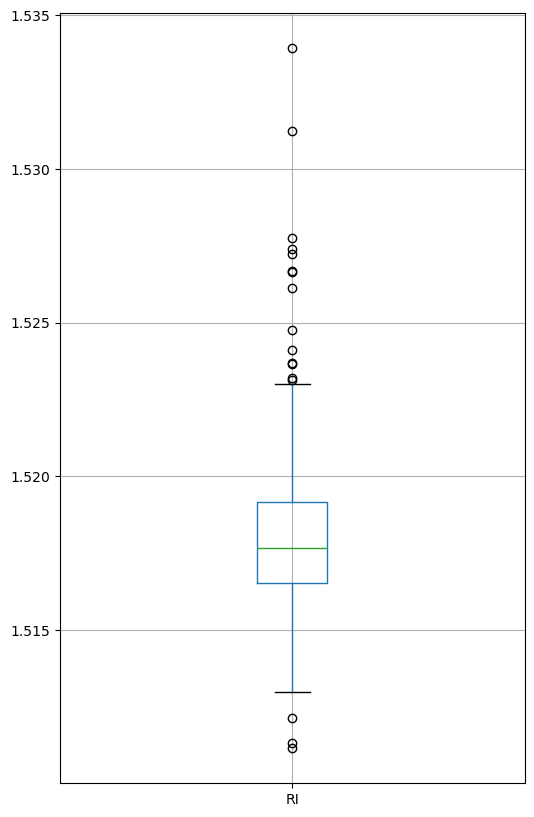

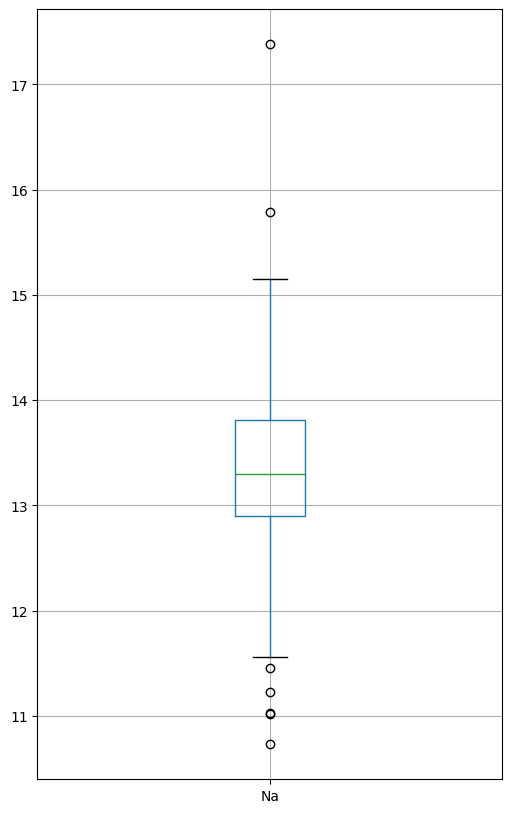

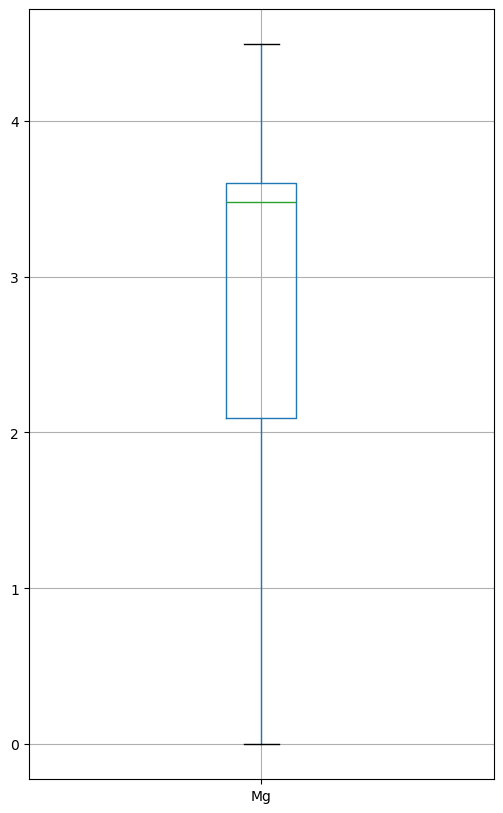

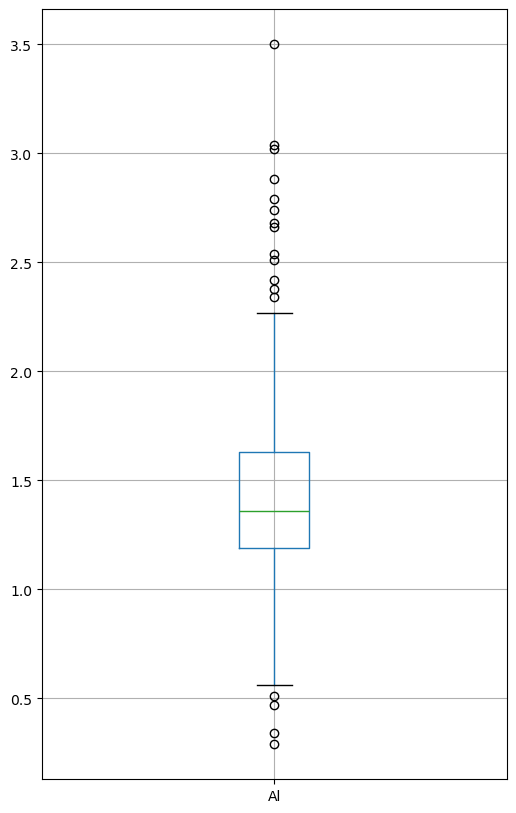

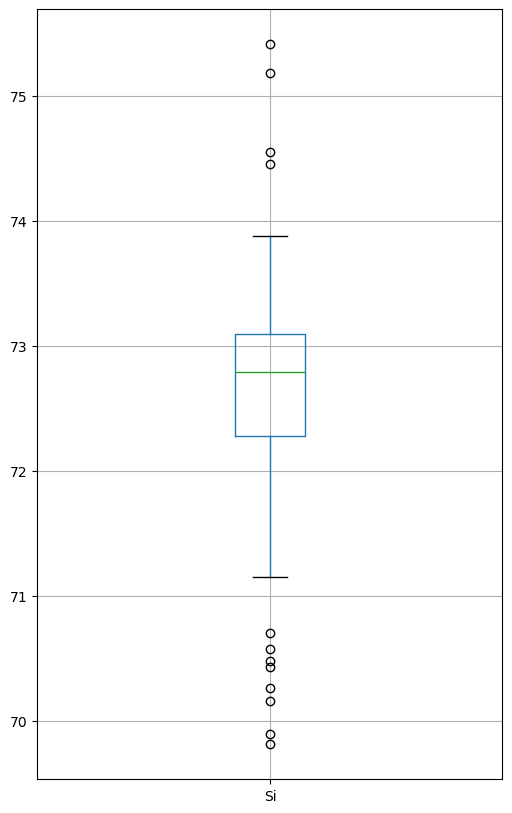

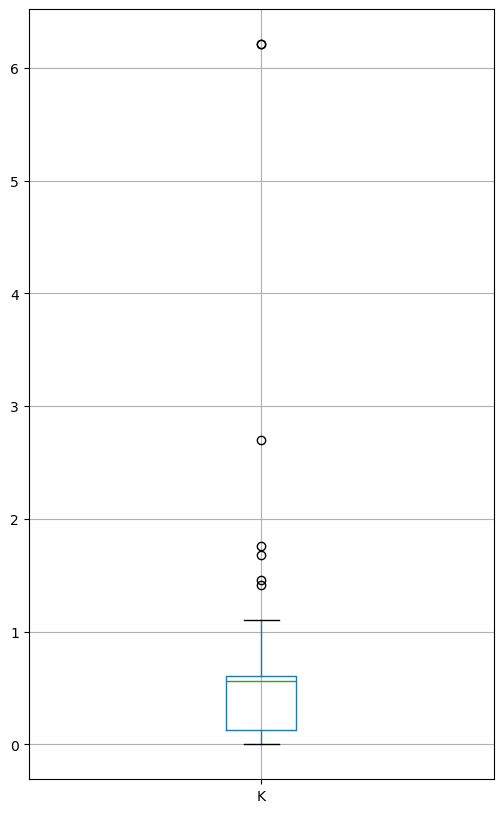

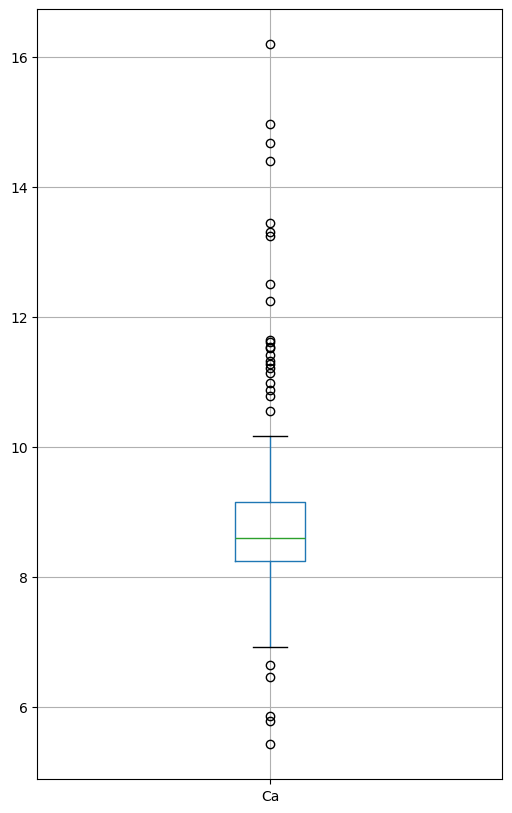

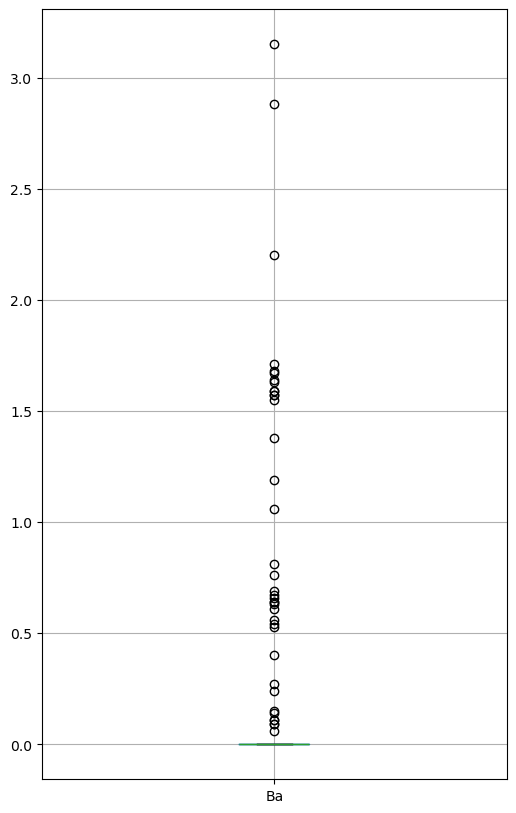

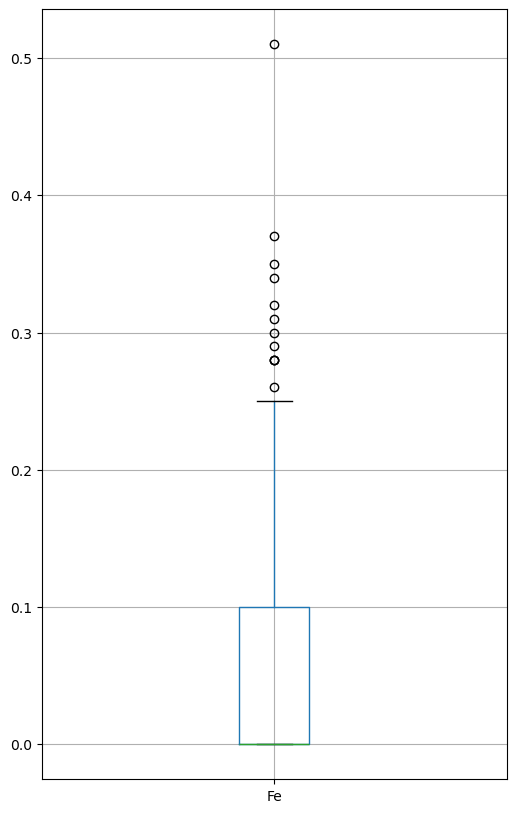

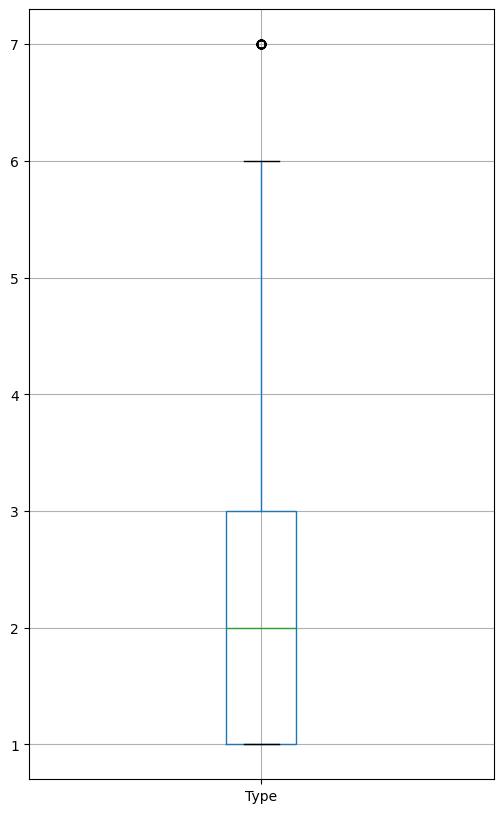

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
n=len(data.columns)
for i in range(0,n):
    plt.figure(figsize=[6,10])
    data.boxplot(column=[data.columns[i]])
    plt.show()

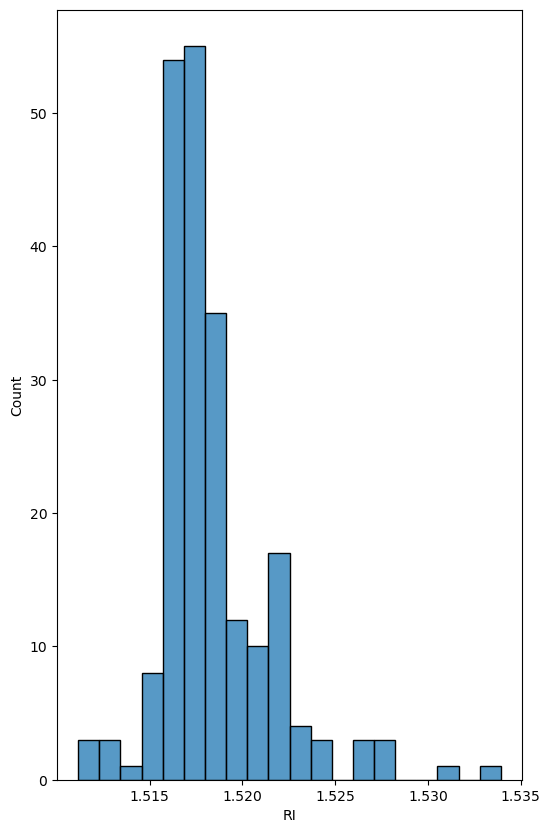

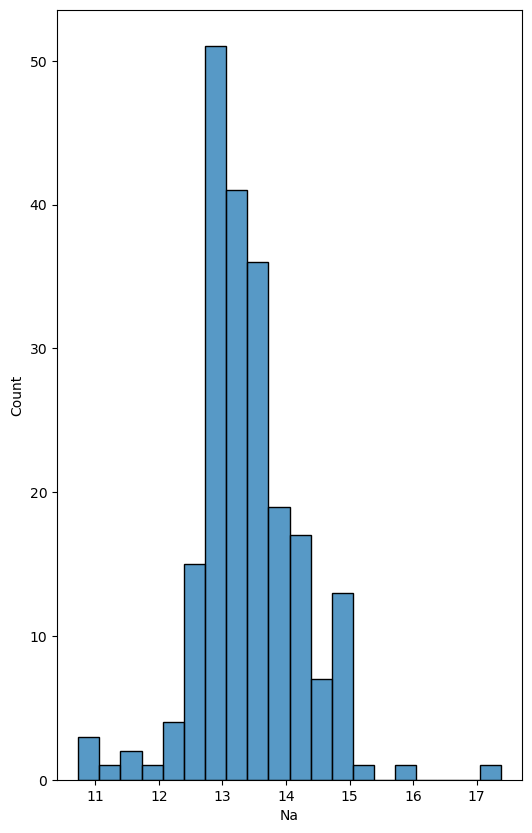

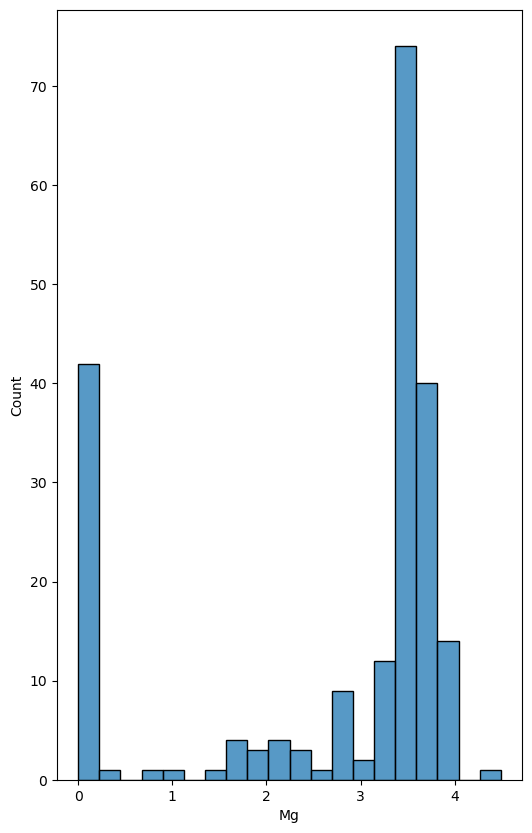

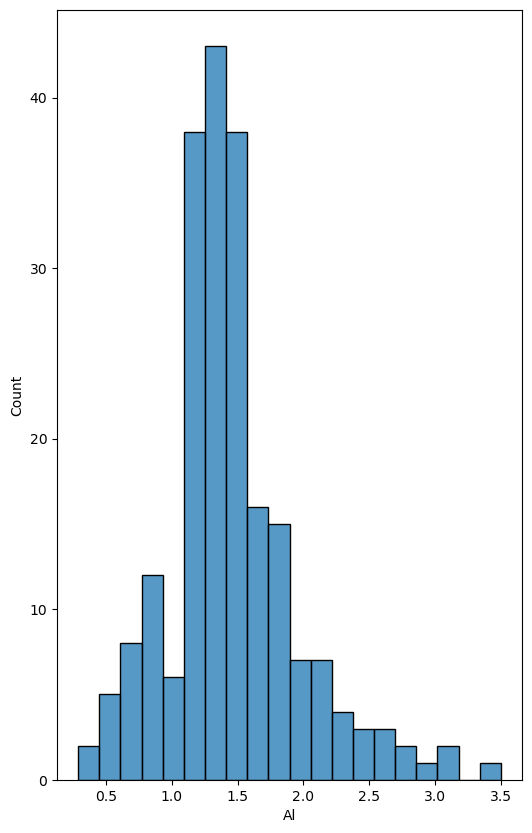

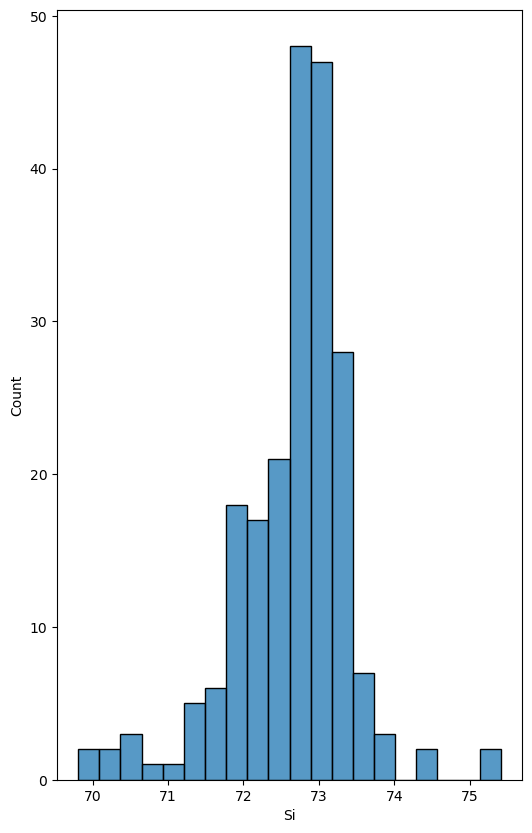

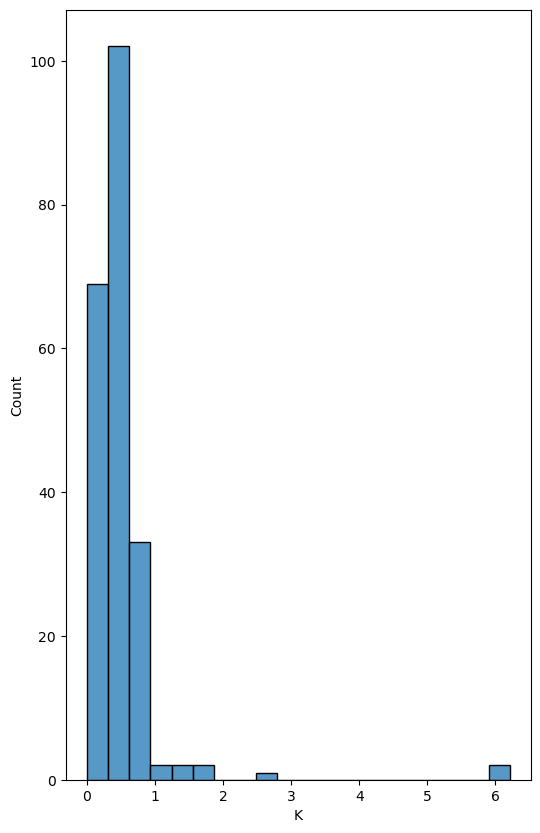

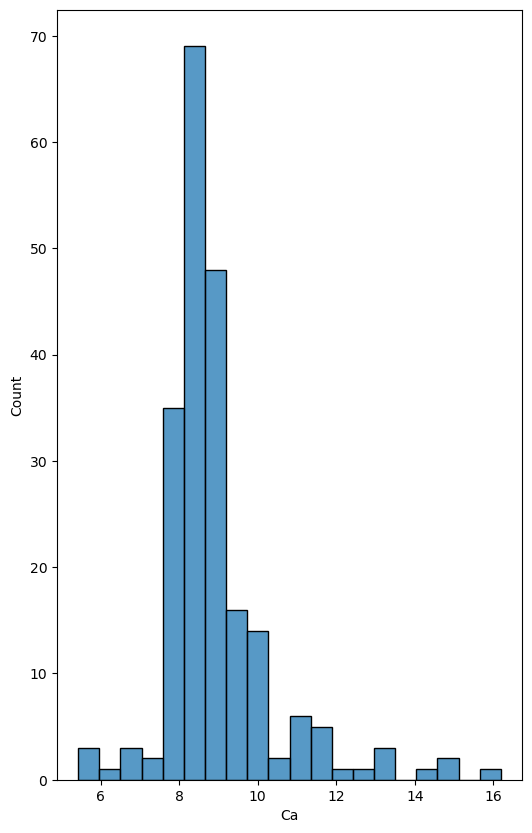

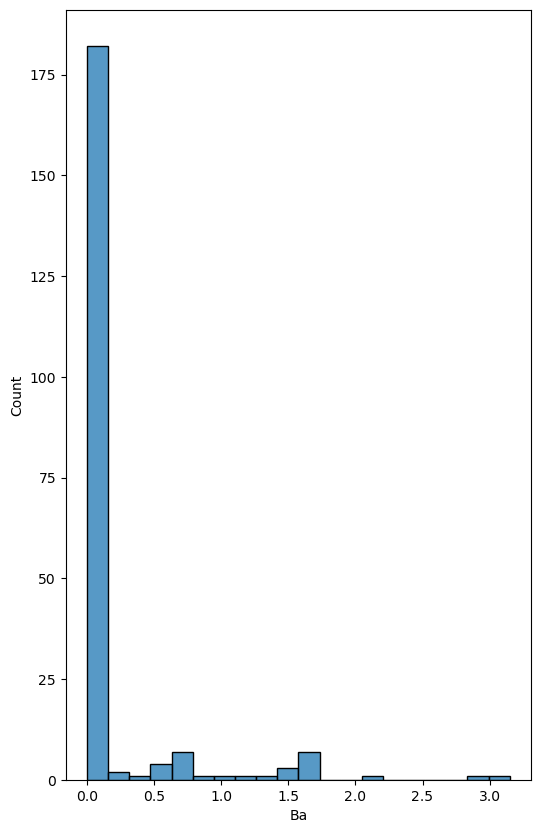

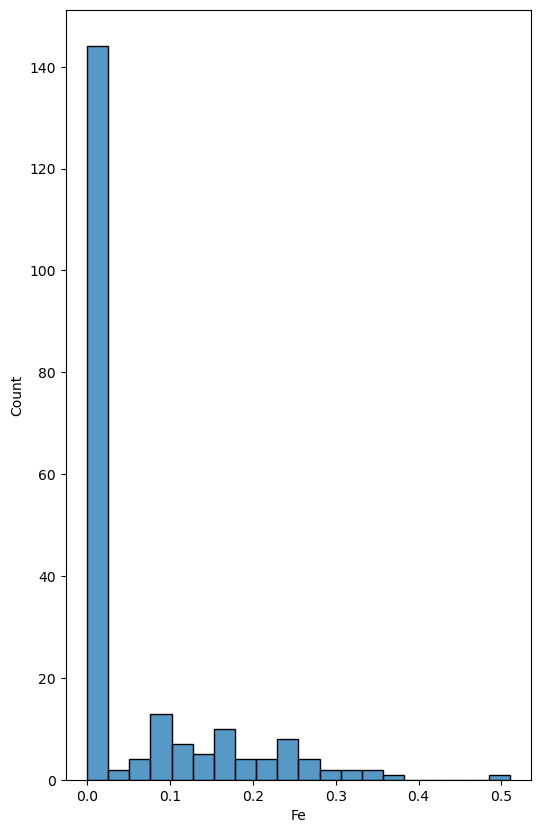

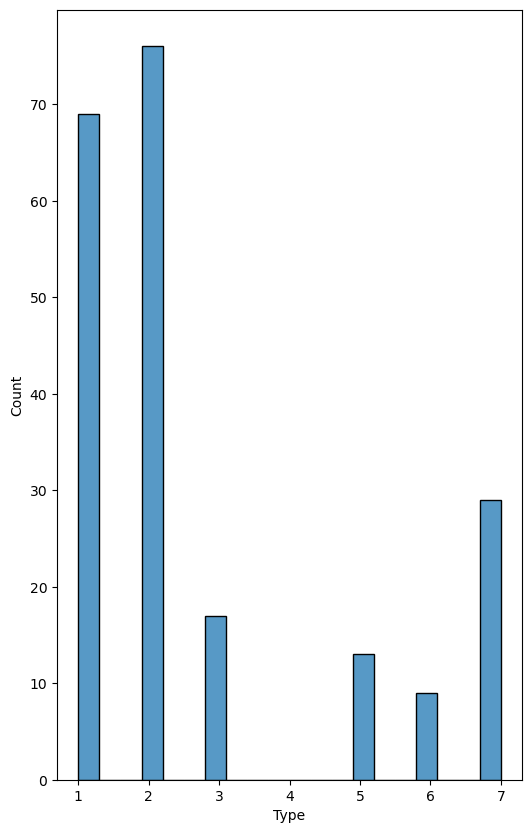

In [14]:
for i in range(0,n):
    plt.figure(figsize=[6,10])
    sns.histplot(data[data.columns[i]],bins=20)
    plt.show()

In [15]:
def remove_outlier(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_range=Q1-(1.5*IQR)
    upper_range=Q3+(1.5*IQR)
    return lower_range,upper_range

In [16]:
data.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [19]:
import numpy as np
lr_RI,ur_RI=remove_outlier(data['RI'])
data['RI']=np.where(data['RI']>ur_RI,ur_RI,data['RI'])
data['RI']=np.where(data['RI']<lr_RI,lr_RI,data['RI'])

lr_Na,ur_Na=remove_outlier(data['Na'])
data['Na']=np.where(data['Na']>ur_Na,ur_Na,data['Na'])
data['Na']=np.where(data['Na']<lr_Na,lr_Na,data['Na'])

lr_Al,ur_Al=remove_outlier(data['Al'])
data['Al']=np.where(data['Al']>ur_Al,ur_Al,data['Al'])
data['Al']=np.where(data['Al']<lr_Al,lr_Al,data['Al'])

lrSi,urSi=remove_outlier(data['Si'])
data['Si']=np.where(data['Si']>urSi,urSi,data['Si'])
data['Si']=np.where(data['Si']<lrSi,lrSi,data['Si'])

lrK,urK=remove_outlier(data['K'])
data['K']=np.where(data['K']>urK,urK,data['K'])
data['K']=np.where(data['K']<lrK,lrK,data['K'])

lrCa,urCa=remove_outlier(data['Ca'])
data['Ca']=np.where(data['Ca']>urCa,urCa,data['Ca'])
data['Ca']=np.where(data['Ca']<lrCa,lrCa,data['Ca'])

lrBa,urBa=remove_outlier(data['Ba'])
data['Ba']=np.where(data['Ba']>urBa,urBa,data['Ba'])
data['Ba']=np.where(data['Ba']<lrBa,lrBa,data['Ba'])

lrFe,urFe=remove_outlier(data['Fe'])
data['Fe']=np.where(data['Fe']>urFe,urFe,data['Fe'])
data['Fe']=np.where(data['Fe']<lrFe,lrFe,data['Fe'])
data.shape

(213, 10)

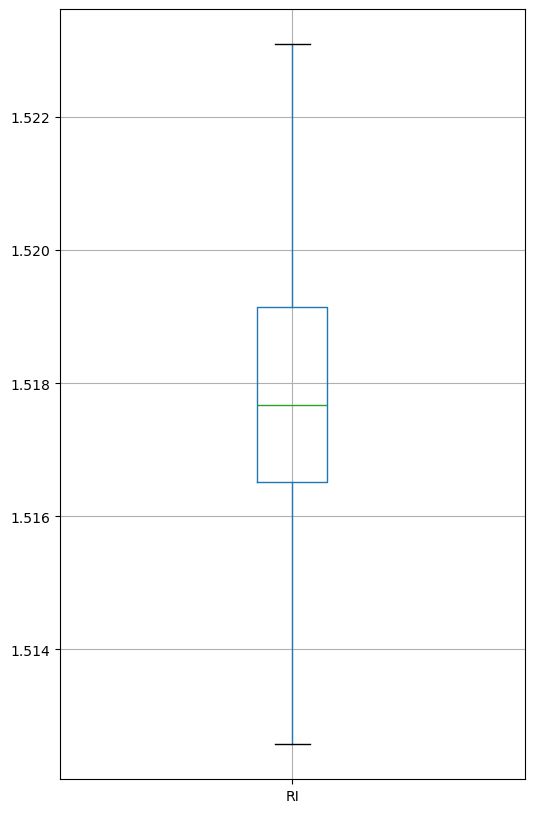

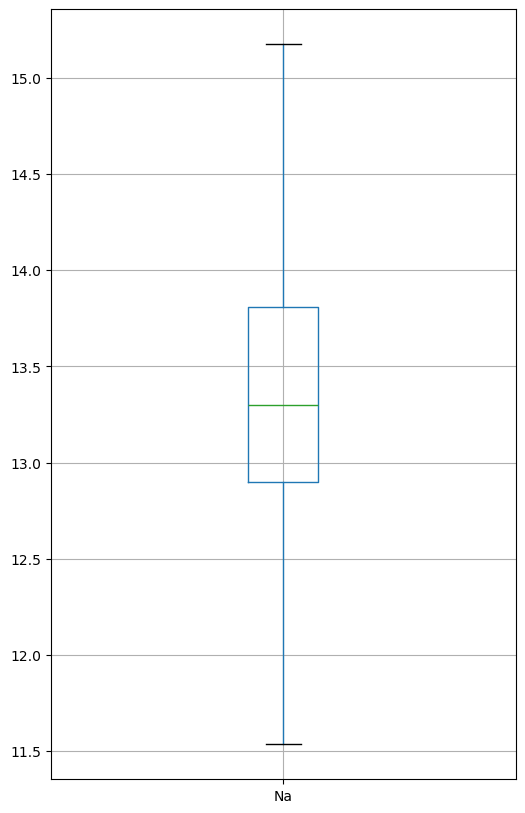

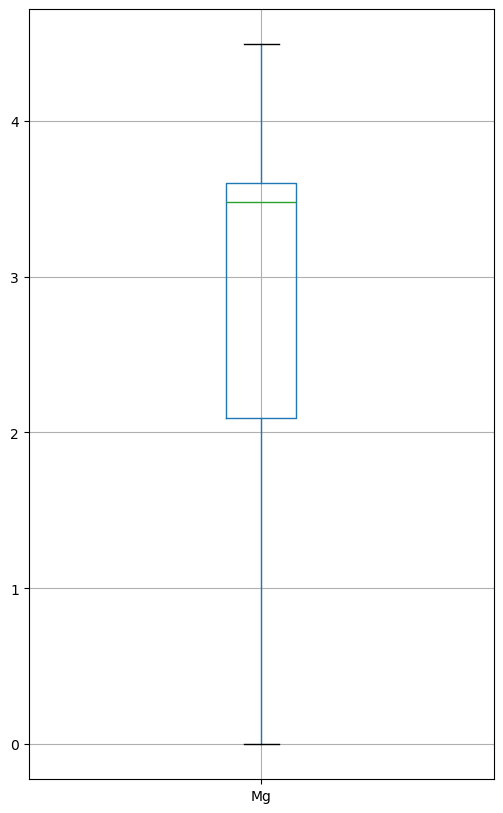

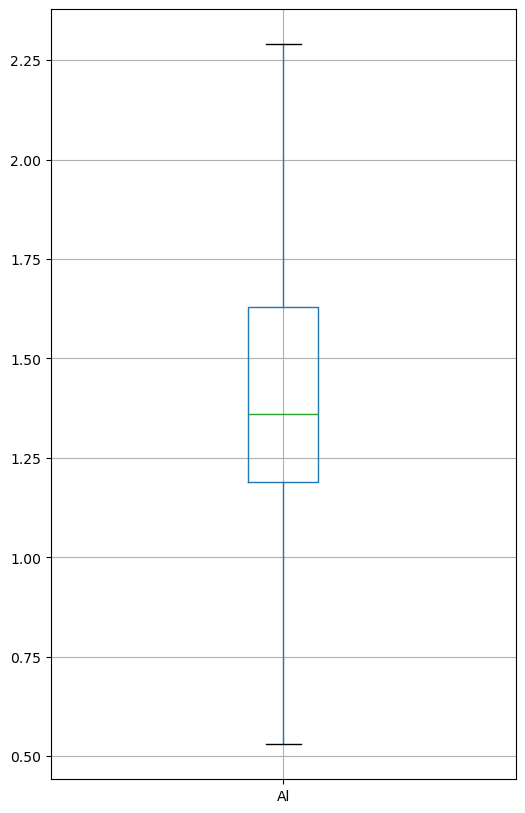

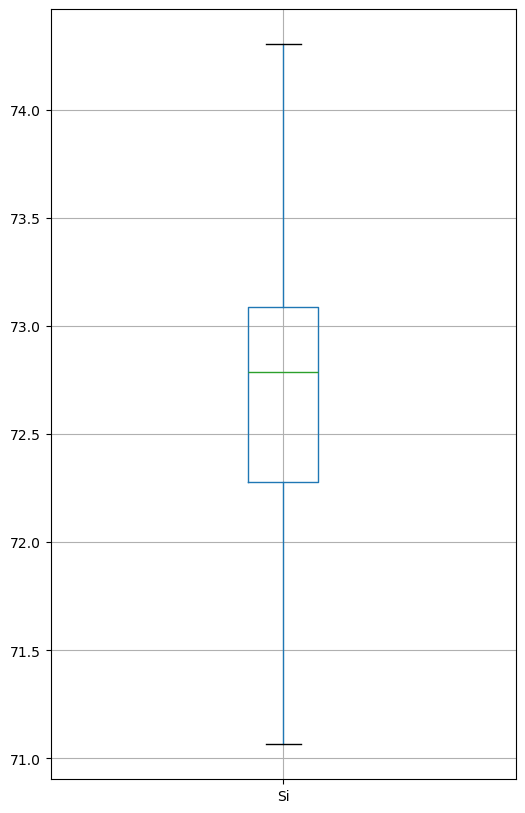

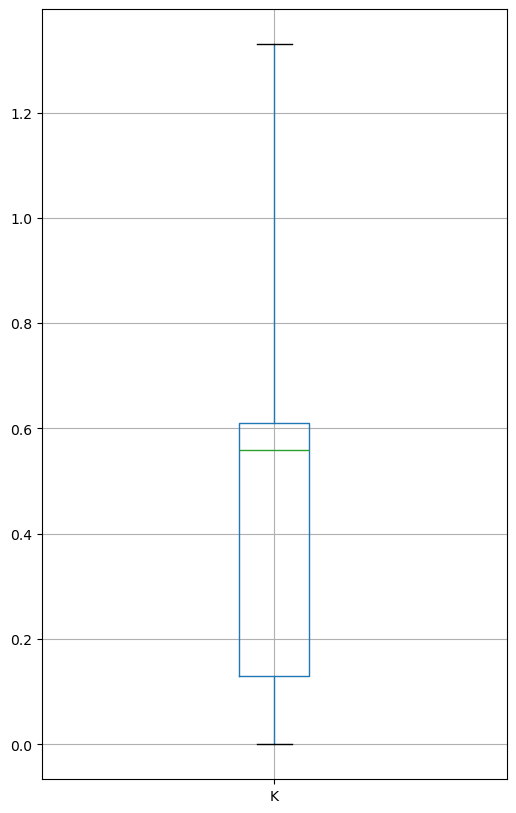

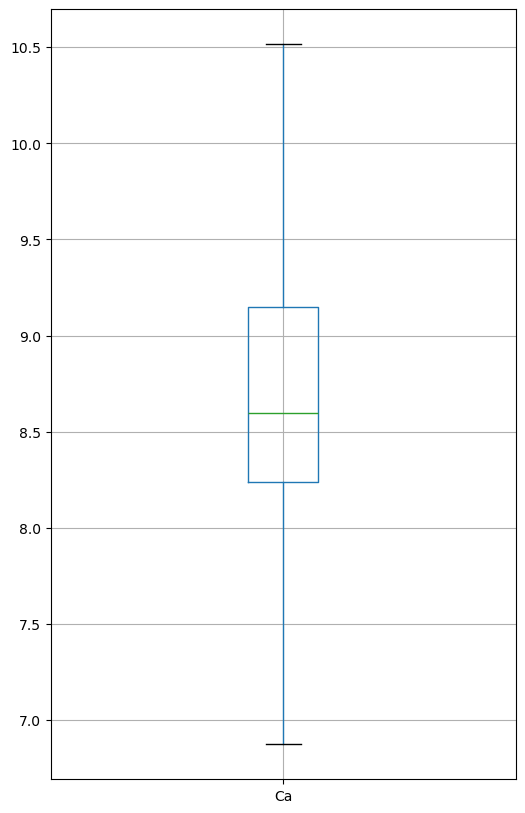

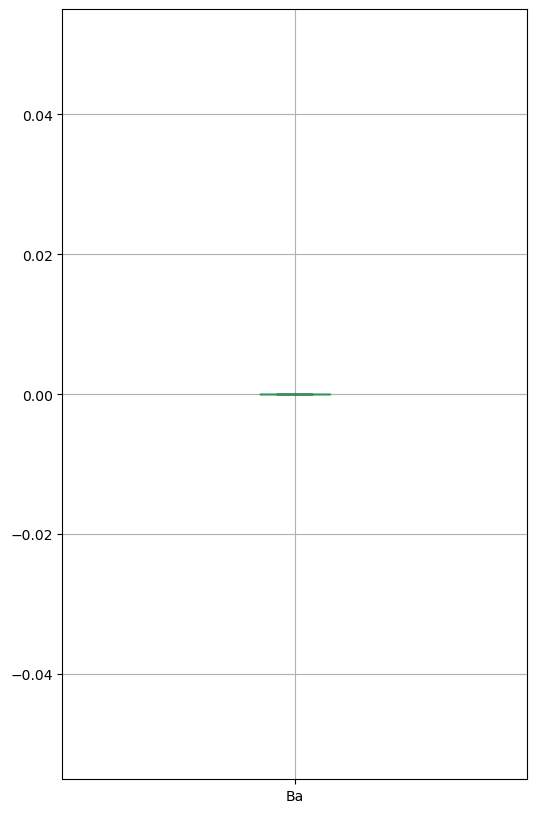

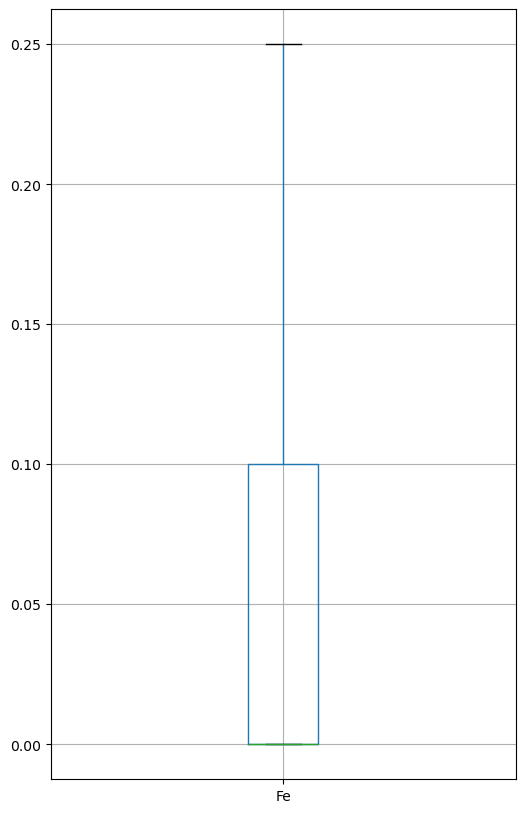

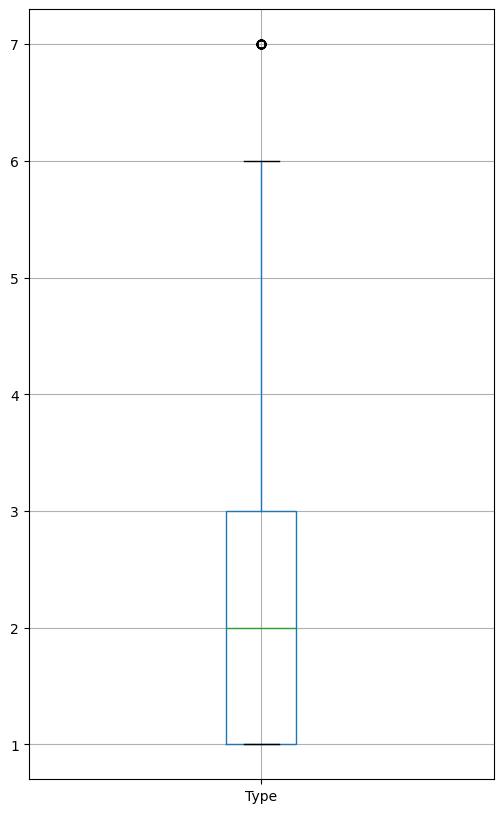

In [20]:
for i in range(0,n):
    plt.figure(figsize=[6,10])
    data.boxplot(column=[data.columns[i]])
    plt.show()

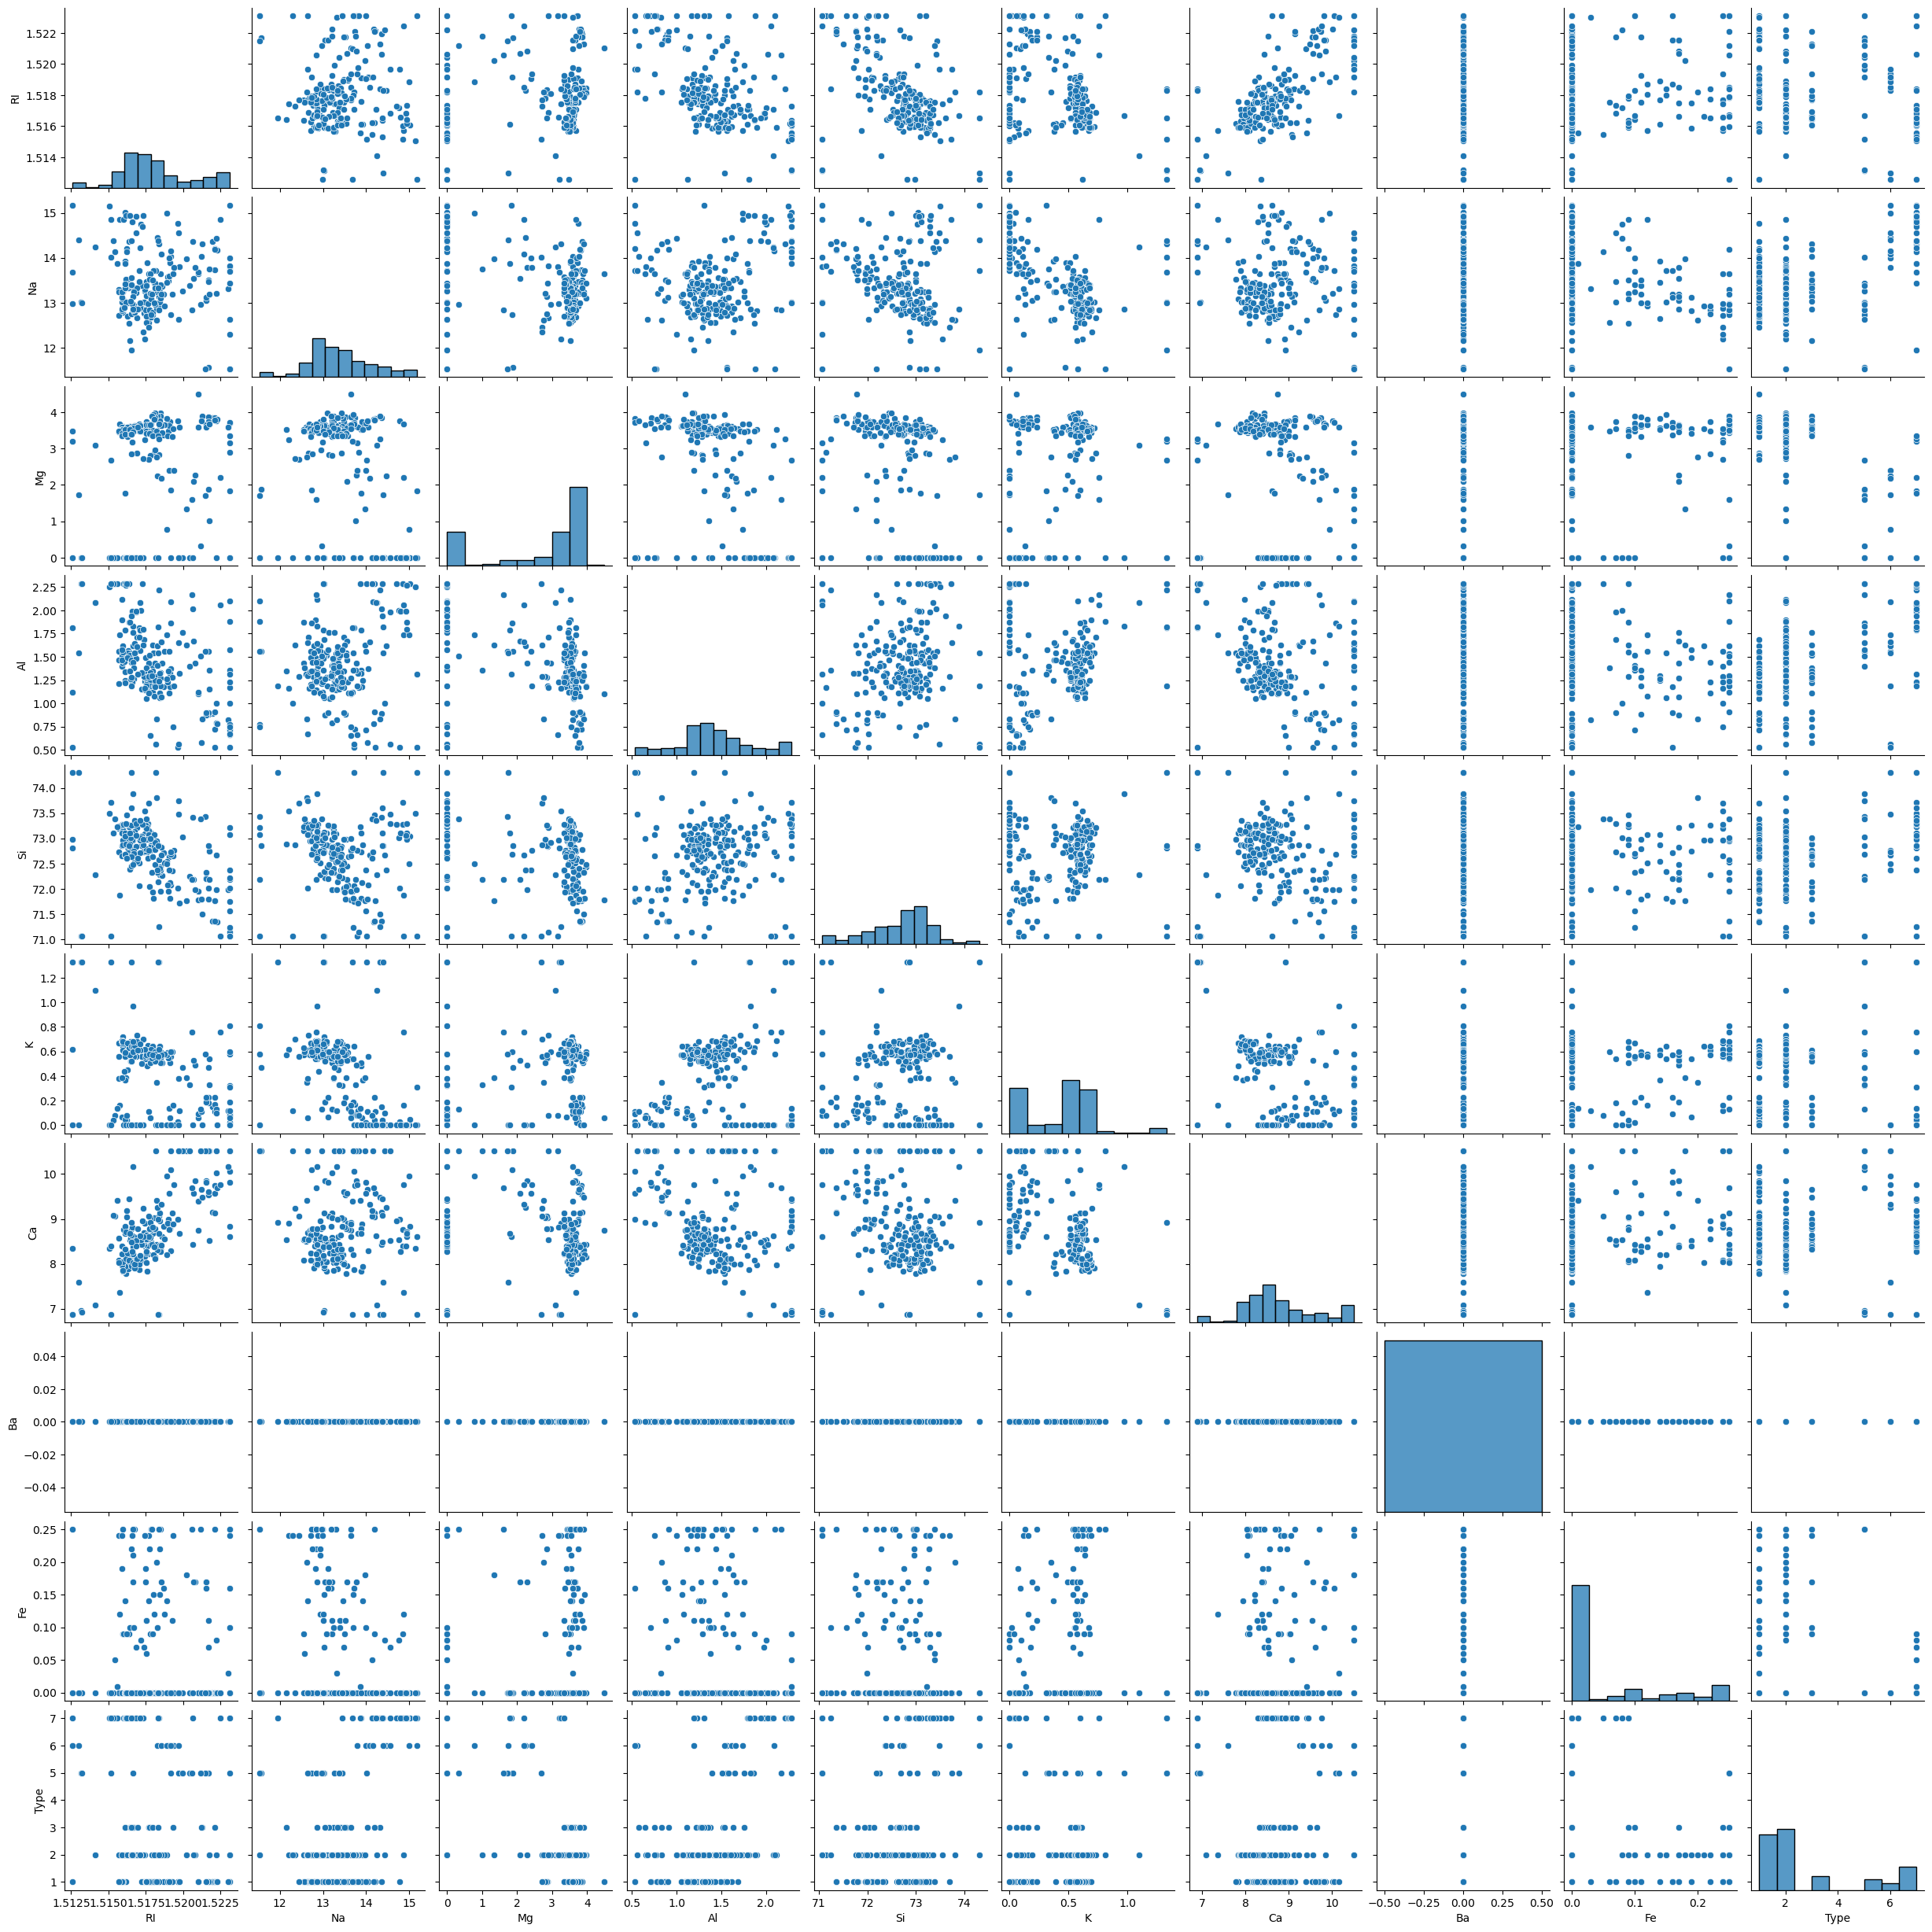

In [22]:
sns.pairplot(data)
plt.show()

4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score

In [25]:
x=data.drop(['Type'],axis=1)
y=data['Type']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print(x_scaled)

[[ 1.21609303  0.3226798   1.25723832 ... -0.04441938  0.
  -0.62110164]
 [-0.22720718  0.6605561   0.63931074 ... -1.11573287  0.
  -0.62110164]
 [-0.83424227  0.17401423  0.6045957  ... -1.17395642  0.
  -0.62110164]
 ...
 [ 1.06327301  1.29576355 -1.86017161 ... -0.40540545  0.
  -0.62110164]
 [-0.69415725  1.32279365 -1.86017161 ... -0.3588266   0.
  -0.62110164]
 [-0.43945721  1.12006787 -1.86017161 ... -0.19580063  0.
  -0.62110164]]


In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=42)
print(x_train)
print(x_test)
print(y_train)
print(y_test)

[[ 1.033558   -0.74500931 -0.74234756 ...  1.06182824  0.
   2.30318328]
 [-0.59652224 -0.82609963  0.58376668 ... -1.03421988  0.
  -0.62110164]
 [ 1.43258806 -0.47470827  0.67402577 ...  1.23649891  0.
   1.36741211]
 ...
 [-0.95310229 -0.21792228  0.45879257 ... -0.66158911  0.
  -0.62110164]
 [-2.18839747  1.34982376 -0.65208848 ... -1.39520595  0.
  -0.62110164]
 [ 2.10117566  0.53892063  0.32687544 ...  2.01087225  0.
  -0.62110164]]
[[-2.52677185e-01 -5.42283533e-01  6.39310737e-01 -1.54740767e-01
   4.82859410e-01  4.20156462e-01 -4.51984294e-01  0.00000000e+00
   6.65583724e-01]
 [-1.20355733e+00  1.32279365e+00 -1.86017161e+00  2.06004236e+00
   6.50490110e-01 -1.31917111e+00  3.39856107e-01  0.00000000e+00
  -6.21101643e-01]
 [ 1.43258806e+00 -4.74708272e-01  6.74025770e-01 -1.32166951e+00
  -5.38163947e-01 -8.26908591e-01  1.23649891e+00  0.00000000e+00
   1.36741211e+00]
 [-8.13017268e-01  1.07952271e+00 -1.86017161e+00  2.06004236e+00
   1.19909967e+00 -1.31917111e+00  2.

In [27]:
from sklearn.ensemble import RandomForestClassifier
# n_estimators defines the number of decision trees in the forest (100 is a common default)
# random_state ensures reproducible results
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Train the model
rf_classifier.fit(x_train, y_train)

# 5. Make predictions on the test set
y_pred = rf_classifier.predict(x_test)
print(y_pred)

[1 7 1 7 2 2 1 2 2 1 2 5 2 2 6 5 7 1 1 2 1 7 7 7 2 5 1 1 6 1 1 2 3 2 2 7 5
 3 2 2 1 2 1 2 1 2 5 1 5 2 1 1 1 2 1 2 2 1 5 1 2 2 1 7]


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
# For multi-class or multi-label problems, use 'average' parameter
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(classification_report(y_test, y_pred))

Accuracy:  0.7500
Precision: 0.7824
Recall:    0.7500
F1-Score:  0.7497
              precision    recall  f1-score   support

           1       0.73      0.89      0.80        18
           2       0.70      0.67      0.68        24
           3       1.00      0.50      0.67         4
           5       0.57      1.00      0.73         4
           6       1.00      0.67      0.80         3
           7       1.00      0.73      0.84        11

    accuracy                           0.75        64
   macro avg       0.83      0.74      0.75        64
weighted avg       0.78      0.75      0.75        64



In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_clf.fit(x_train, y_train)

y_pred_1=gb_clf.predict(x_test)
print(y_pred_1)

[1 7 1 7 2 2 1 2 2 1 2 5 2 2 6 5 7 1 1 6 2 7 7 7 1 5 1 1 6 1 6 2 3 2 2 7 5
 3 2 2 3 5 1 2 1 2 2 2 5 2 1 1 1 2 1 1 2 1 5 1 2 2 1 7]


In [34]:
accuracy1 = accuracy_score(y_test, y_pred)
# For multi-class or multi-label problems, use 'average' parameter
precision1 = precision_score(y_test, y_pred_1, average='weighted')
recall1 = recall_score(y_test, y_pred_1, average='weighted')
f1_1 = f1_score(y_test, y_pred_1, average='weighted')

print(f"Accuracy:  {accuracy1:.4f}")
print(f"Precision: {precision1:.4f}")
print(f"Recall:    {recall1:.4f}")
print(f"F1-Score:  {f1_1:.4f}")
print(classification_report(y_test, y_pred_1))

Accuracy:  0.7500
Precision: 0.8216
Recall:    0.7969
F1-Score:  0.7993
              precision    recall  f1-score   support

           1       0.80      0.89      0.84        18
           2       0.86      0.79      0.83        24
           3       0.67      0.50      0.57         4
           5       0.57      1.00      0.73         4
           6       0.50      0.67      0.57         3
           7       1.00      0.73      0.84        11

    accuracy                           0.80        64
   macro avg       0.73      0.76      0.73        64
weighted avg       0.82      0.80      0.80        64

